In [1]:
import torch
import segmentation_models_pytorch as smp
import timm
import wandb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print(f"PyTorch     : {torch.__version__}")
print(f"CUDA        : {torch.cuda.is_available()}")
print(f"GPU count   : {torch.cuda.device_count()}")
print(f"GPU name    : {torch.cuda.get_device_name(0)}")
print(f"timm        : {timm.__version__}")
print(f"wandb       : {wandb.__version__}")
print("\n✅ All libraries ready!")

/home/lhotse1/student/btech2023/achanta/miniconda3/envs/cv311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch     : 2.6.0+cu124
CUDA        : True
GPU count   : 2
GPU name    : Tesla V100-PCIE-32GB
timm        : 1.0.27
wandb       : 0.22.3

✅ All libraries ready!


In [2]:
import wandb
wandb.login()

wandb: Currently logged in as: chandinigunna06 (chandinigunna06-iiest-shibpur) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [3]:
wandb.init(
    project="xray-classification",
    name="01-preprocessing",
    config={
        "dataset": "NIH ChestXray14",
        "image_size": 224,
        "batch_size": 32,
        "num_classes": 15
    }
)

print("✅ Wandb project initialized!")
print(f"Project URL: {wandb.run.url}")

✅ Wandb project initialized!
Project URL: https://wandb.ai/chandinigunna06-iiest-shibpur/xray-classification/runs/gitzzn79


In [6]:
import os

# Check images-224 folder
img_dir = '/home/lhotse1/student/btech2023/achanta/segmentation_project/data/NIH/images-224'

for item in os.listdir(img_dir):
    full_path = os.path.join(img_dir, item)
    if os.path.isdir(full_path):
        count = len(os.listdir(full_path))
        print(f"📁 {item}/ → {count} images")
    else:
        print(f"📄 {item}")

# Check CSV
import pandas as pd
df = pd.read_csv('/home/lhotse1/student/btech2023/achanta/segmentation_project/data/NIH/Data_Entry_2017.csv')
print(f"\n📊 Total rows in CSV: {len(df)}")
print(f"📊 Columns: {df.columns.tolist()}")
print(df.head(3))
        

📁 images-224/ → 112120 images

📊 Total rows in CSV: 112120
📊 Columns: ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11']
        Image Index          Finding Labels  Follow-up #  Patient ID  \
0  00000001_000.png            Cardiomegaly            0           1   
1  00000001_001.png  Cardiomegaly|Emphysema            1           1   
2  00000001_002.png   Cardiomegaly|Effusion            2           1   

  Patient Age Patient Gender View Position  OriginalImage[Width  Height]  \
0        058Y              M            PA                 2682     2749   
1        058Y              M            PA                 2894     2729   
2        058Y              M            PA                 2500     2048   

   OriginalImagePixelSpacing[x     y]  Unnamed: 11  
0                        0.143  0.143          NaN  
1                        0.143 

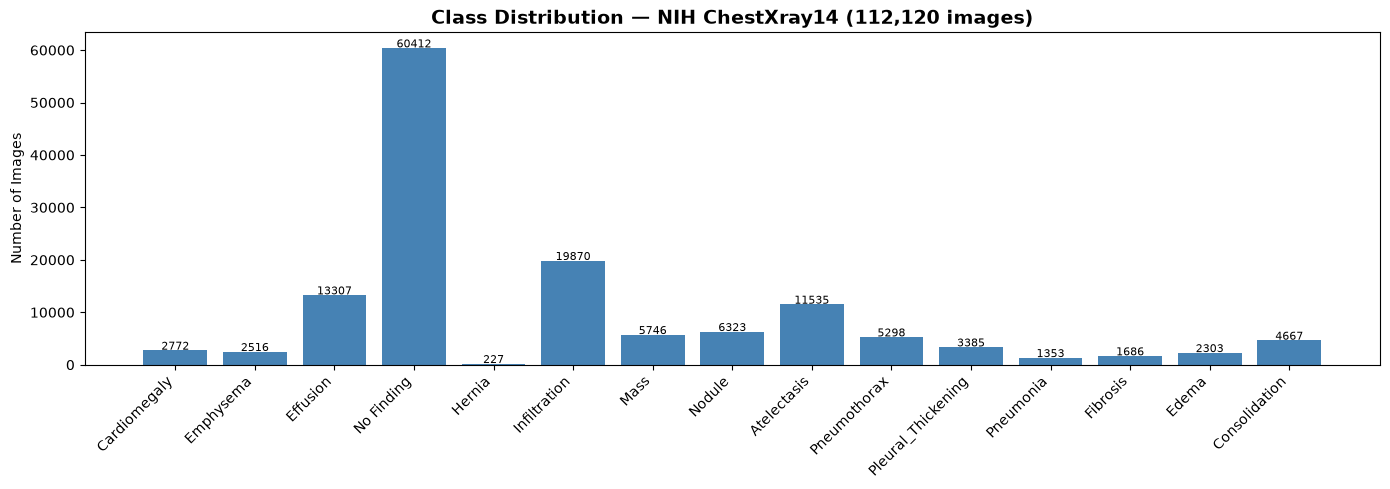


Class counts:
  No Finding                →  60412 images
  Infiltration              →  19870 images
  Effusion                  →  13307 images
  Atelectasis               →  11535 images
  Nodule                    →   6323 images
  Mass                      →   5746 images
  Pneumothorax              →   5298 images
  Consolidation             →   4667 images
  Pleural_Thickening        →   3385 images
  Cardiomegaly              →   2772 images
  Emphysema                 →   2516 images
  Edema                     →   2303 images
  Fibrosis                  →   1686 images
  Pneumonia                 →   1353 images
  Hernia                    →    227 images

✅ Distribution logged to wandb!


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

df = pd.read_csv('/home/lhotse1/student/btech2023/achanta/segmentation_project/data/NIH/Data_Entry_2017.csv')

# Count all diseases
all_labels = []
for label in df['Finding Labels']:
    all_labels.extend(label.split('|'))

counts = Counter(all_labels)

# Plot
plt.figure(figsize=(14, 5))
bars = plt.bar(counts.keys(), counts.values(), color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title('Class Distribution — NIH ChestXray14 (112,120 images)', fontsize=14, fontweight='bold')
plt.ylabel('Number of Images')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 100,
             str(bar.get_height()),
             ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('../results/class_distribution.png', dpi=150)
plt.show()

print("\nClass counts:")
for label, count in sorted(counts.items(), key=lambda x: -x[1]):
    print(f"  {label:25s} → {count:6d} images")

# Log to wandb
wandb.log({'class_distribution': wandb.Image('../results/class_distribution.png')})
print("\n✅ Distribution logged to wandb!")

In [8]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from collections import Counter

CLASSES = [
    'Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration',
    'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax',
    'Consolidation', 'Edema', 'Emphysema', 'Fibrosis',
    'Pleural_Thickening', 'Hernia', 'No Finding'
]

# Split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_df, val_df  = train_test_split(train_df, test_size=0.1, random_state=42)

print(f"Train : {len(train_df):6d} images")
print(f"Val   : {len(val_df):6d} images")
print(f"Test  : {len(test_df):6d} images")

# Compute class weights
all_labels = []
for label in train_df['Finding Labels']:
    all_labels.extend(label.split('|'))

label_counts = Counter(all_labels)
total        = sum(label_counts.values())

class_weights = {}
for cls in CLASSES:
    class_weights[cls] = round(total / (len(CLASSES) * label_counts[cls]), 3)

print("\nClass Weights (higher = rarer class):")
for cls, w in sorted(class_weights.items(), key=lambda x: -x[1]):
    bar = "█" * int(w)
    print(f"  {cls:25s} → {w:.3f}  {bar}")

# Save splits
train_df.to_csv('../data/train_split.csv', index=False)
val_df.to_csv('../data/val_split.csv',     index=False)
test_df.to_csv('../data/test_split.csv',   index=False)

import pickle
with open('../data/data_config.pkl', 'wb') as f:
    pickle.dump({
        'train_df':     train_df,
        'val_df':       val_df,
        'test_df':      test_df,
        'classes':      CLASSES,
        'class_weights': class_weights,
        'data_dir':     '/home/lhotse1/student/btech2023/achanta/segmentation_project/data/NIH/images-224/images-224'
    }, f)

wandb.log({
    'train_size': len(train_df),
    'val_size':   len(val_df),
    'test_size':  len(test_df)
})

print("\n✅ Splits saved! data_config.pkl ready for next notebooks!")

Train :  80726 images
Val   :   8970 images
Test  :  22424 images

Class Weights (higher = rarer class):
  Hernia                    → 42.517  ██████████████████████████████████████████
  Pneumonia                 → 7.086  ███████
  Fibrosis                  → 5.473  █████
  Edema                     → 4.066  ████
  Emphysema                 → 3.744  ███
  Cardiomegaly              → 3.381  ███
  Pleural_Thickening        → 2.771  ██
  Consolidation             → 2.004  ██
  Pneumothorax              → 1.777  █
  Mass                      → 1.632  █
  Nodule                    → 1.495  █
  Atelectasis               → 0.811  
  Effusion                  → 0.703  
  Infiltration              → 0.473  
  No Finding                → 0.157  

✅ Splits saved! data_config.pkl ready for next notebooks!


In [9]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
import numpy as np

IMAGE_DIR = '/home/lhotse1/student/btech2023/achanta/segmentation_project/data/NIH/images-224/images-224'
IMAGE_SIZE = 224
BATCH_SIZE = 32

class NIHChestXrayDataset(Dataset):
    def __init__(self, df, data_dir, classes, transform=None):
        self.df        = df.reset_index(drop=True)
        self.data_dir  = data_dir
        self.classes   = classes
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.data_dir, row['Image Index'])
        image    = Image.open(img_path).convert('RGB')

        # Multi-label encoding
        label_vec = torch.zeros(len(self.classes))
        for disease in row['Finding Labels'].split('|'):
            if disease in self.classes:
                label_vec[self.classes.index(disease)] = 1.0

        if self.transform:
            image = self.transform(image)

        return image, label_vec, row['Image Index']

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Create datasets
train_dataset = NIHChestXrayDataset(train_df, IMAGE_DIR, CLASSES, train_transform)
val_dataset   = NIHChestXrayDataset(val_df,   IMAGE_DIR, CLASSES, val_transform)
test_dataset  = NIHChestXrayDataset(test_df,  IMAGE_DIR, CLASSES, val_transform)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=8, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=8, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=8, pin_memory=True)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")
print("\n✅ DataLoaders ready!")

Train batches : 2523
Val batches   : 281
Test batches  : 701

✅ DataLoaders ready!


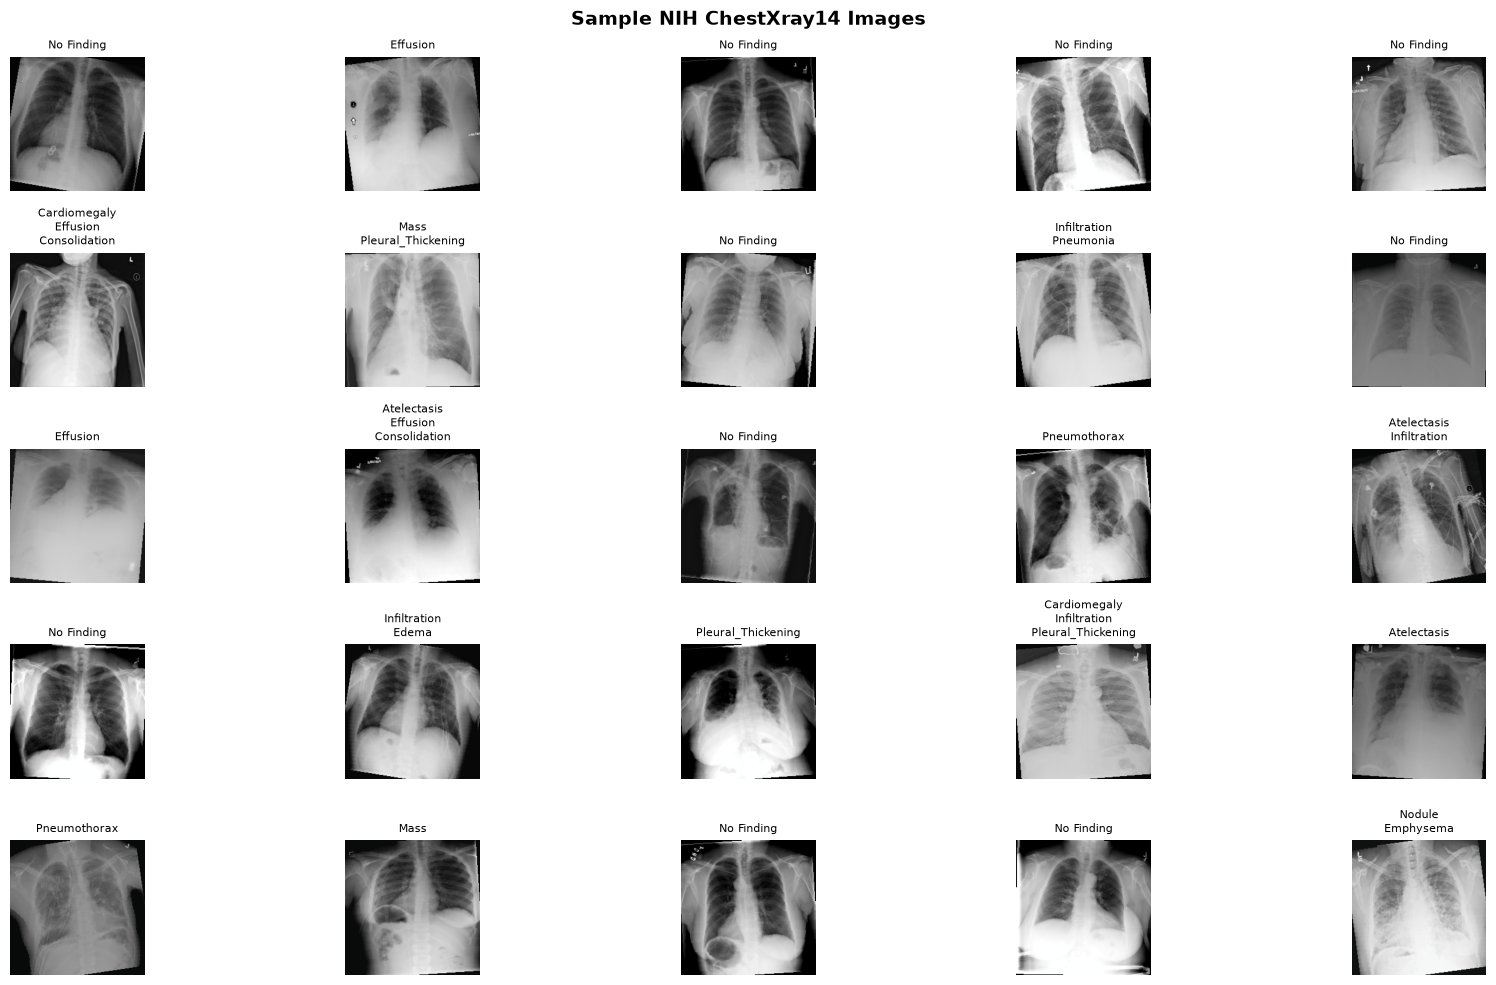

✅ Sample images logged to wandb!


In [12]:
import matplotlib.pyplot as plt
import numpy as np

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

# Get one batch
images, labels, paths = next(iter(train_loader))

fig, axes = plt.subplots(5, 5, figsize=(18, 10))
fig.suptitle('Sample NIH ChestXray14 Images', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    img = images[i].numpy().transpose(1, 2, 0)
    img = (img * std + mean).clip(0, 1)

    # Get disease labels for this image
    label_indices = labels[i].numpy().nonzero()[0]
    label_names   = [CLASSES[j] for j in label_indices]
    title         = '\n'.join(label_names) if label_names else 'No Finding'

    ax.imshow(img, cmap='gray')
    ax.set_title(title, fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig('../results/sample_images.png', dpi=150)
plt.show()

wandb.log({'sample_images': wandb.Image('../results/sample_images.png')})
print("✅ Sample images logged to wandb!")


In [13]:
import pickle

# Save all config for next notebooks
with open('../data/data_config.pkl', 'wb') as f:
    pickle.dump({
        'train_df':      train_df,
        'val_df':        val_df,
        'test_df':       test_df,
        'classes':       CLASSES,
        'class_weights': class_weights,
        'image_dir':     IMAGE_DIR,
        'image_size':    IMAGE_SIZE,
        'batch_size':    BATCH_SIZE
    }, f)

print("✅ data_config.pkl saved!")

# Log final summary to wandb
wandb.log({
    'total_images': len(df),
    'train_size':   len(train_df),
    'val_size':     len(val_df),
    'test_size':    len(test_df),
    'num_classes':  len(CLASSES)
})

wandb.finish()

print("\n" + "="*50)
print("  NOTEBOOK 1 COMPLETE!")
print("="*50)
print(f"  Total Images : {len(df):,}")
print(f"  Train        : {len(train_df):,}")
print(f"  Val          : {len(val_df):,}")
print(f"  Test         : {len(test_df):,}")
print(f"  Classes      : {len(CLASSES)}")
print("="*50)
print("\n👉 Now open 02_segmentation.ipynb!")

✅ data_config.pkl saved!


num_classes,▁
test_size,▁▁
total_images,▁
train_size,▁▁
val_size,▁▁
num_classes,15
test_size,22424
total_images,112120
train_size,80726
val_size,8970



  NOTEBOOK 1 COMPLETE!
  Total Images : 112,120
  Train        : 80,726
  Val          : 8,970
  Test         : 22,424
  Classes      : 15

👉 Now open 02_segmentation.ipynb!
